# Recommendation system for user

In this exercise, we develop a model that suggests similar products based on a given item. We utilize `Word2Vec()` to train the model and construct a recommendation system.
Data: https://www.kaggle.com/datasets/samantas2020/online-retail-xlsx

**Steps to Solve This Exercise**

1. Data preprocessing (Download, Handle Missing Value and Split dataset (train set: 90%,test set:10%))
2. Build a representation model for products in the training dataset. (Model, Vocabulary and Training)
3. Visualize word2vec Embeddings
4. Build a function to compute the similarity of products.

This result is based on the vector of a single product. What happens if we want to recommend products to a customer based on the products they have previously chosen?

In [13]:
# Import libraries
import os, shutil
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

## Load dataset

In [6]:
import kagglehub

data_dir = "./data"

# Download latest version
path = kagglehub.dataset_download("samantas2020/online-retail-xlsx", )
for filename in os.listdir(path):
    src = os.path.join(path, filename)
    dst = os.path.join(data_dir, filename)
    shutil.copy(src, dst)
    
print("Path to dataset files:", data_dir)

file_path = os.path.join(data_dir, "Online Retail.xlsx")
if os.path.exists(file_path):
    print("File path is:", file_path)
else:
    print("Downloading dataset is not successfully")    

Path to dataset files: ./data
File path is: ./data/Online Retail.xlsx


### Load dataset into DF

In [9]:
df = pd.read_excel(file_path)
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [11]:
print("Original shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Original shape: (541909, 8)

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


## Preprocessing data

In [42]:
def preprocessing(df: pd.DataFrame) -> pd.DataFrame:
    print(f"Original shape: {df.shape}\n")
    print("Missing values:\n", df.isnull().sum())

    # Drop rows with missing Description or CustomerID
    df = df.dropna(subset=['Description', 'CustomerID'])
    
    # Filter invalid rows
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
    # Normalize text
    df['Description'] = (
        df['Description']
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(r'[^A-Z0-9\s]', '', regex=True)
        .str.replace(r'\s+', ' ', regex=True)
    )
    
    df = df[df['Description'] != '']
    df = df[~df['Description'].str.contains('UNKNOWN|ADJUST|DISCOUNT|POSTAGE|CARRIAGE|SAMPLES', na=False)]
    
    df['CustomerID'] = df['CustomerID'].astype(int)

    df = df.reset_index(drop=True)
    print(f"\nCleaned shape: {df.shape}")
    print(f"Unique customers: {df['CustomerID'].nunique()}")
    print(f"Unique products: {df['StockCode'].nunique()}")
    return df


In [43]:
df_processed = preprocessing(df)

Original shape: (541909, 8)

Missing values:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Cleaned shape: (527955, 8)
Unique customers: 5739
Unique products: 3914


In [44]:
def prepare_transactions(df: pd.DataFrame):
    df_sorted = df.sort_values(['InvoiceNo', 'InvoiceDate'])
    transactions = df_sorted.groupby('InvoiceNo')['StockCode'].apply(list).tolist()
    transactions = [t for t in transactions if 2 <= len(t) <= 50]
    
    print(f"Training transactions: {len(transactions)}")
    print(f"Sample: {transactions[0][:10]}")
    return transactions

In [45]:
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)

In [46]:
transactions = prepare_transactions(train_df)

Training transactions: 17848
Sample: ['85123A', '84029E', 71053, '84029G', 22752]


## Train model and evaluation

In [47]:
def train_word2vec(transactions):
    print("Training Word2Vec model...")
    model = Word2Vec(
        sentences=transactions,
        vector_size=150,
        window=10,
        min_count=5,
        sg=1,
        workers=4,
        epochs=30,
        negative=15,
        ns_exponent=0.75,
        alpha=0.025,
        min_alpha=0.0001,
        sample=1e-5,
        hs=0
    )
    print(f"Vocabulary size: {len(model.wv.index_to_key)}")
    return model


In [48]:
model = train_word2vec(transactions)

Training Word2Vec model...
Vocabulary size: 3023


### Visualize the result

In [49]:
def visualize_embeddings(model, n_words=150):
    words = model.wv.index_to_key[:n_words]
    vectors = model.wv[words]
    
    pca = PCA(n_components=2, random_state=42)
    reduced = pca.fit_transform(vectors)
    
    plt.figure(figsize=(14, 10))
    plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.5, s=30)
    
    for i in range(min(50, len(words))):
        plt.annotate(words[i], xy=(reduced[i, 0], reduced[i, 1]), fontsize=7, alpha=0.7)
    
    plt.title("Word2Vec Product Embeddings")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

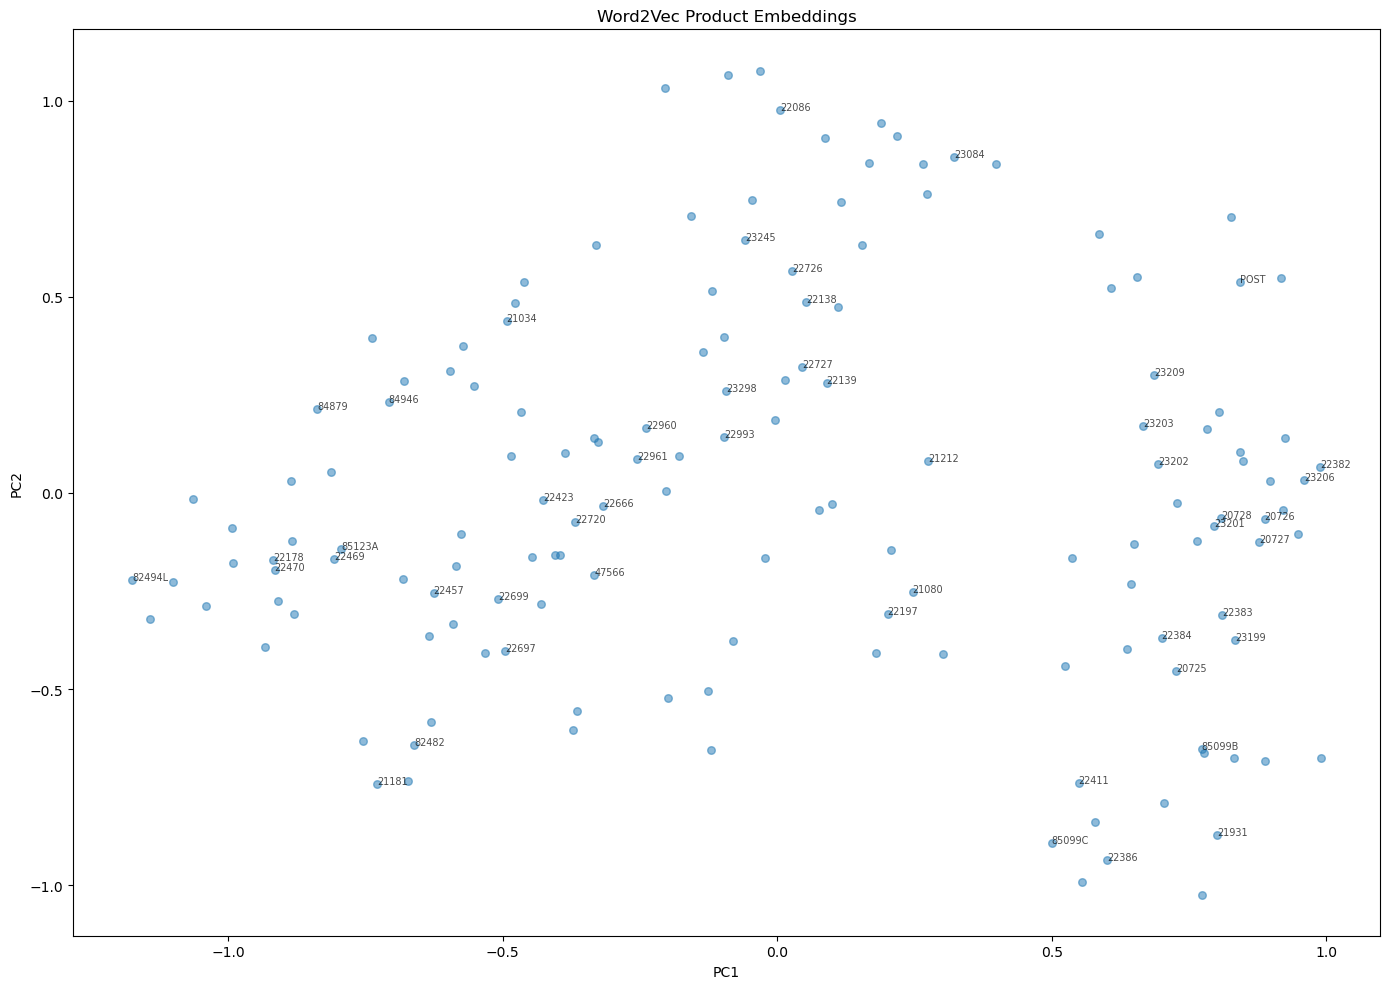

In [50]:
visualize_embeddings(model, n_words=150)

## Testing in real data to evaluate model

In [51]:
def recommend_similar(model, product_code, df, top_n=10):
    if product_code not in model.wv:
        return f"Product {product_code} not in vocabulary"
    
    similar = model.wv.most_similar(product_code, topn=top_n)
    
    results = []
    for code, score in similar:
        desc_match = df[df['StockCode'] == code]['Description']
        desc = desc_match.iloc[0] if len(desc_match) > 0 else 'N/A'
        results.append({
            'Rank': len(results) + 1,
            'StockCode': code,
            'Description': desc,
            'Similarity': f"{score:.4f}"
        })
    
    return pd.DataFrame(results)


def recommend_from_basket(model, product_codes, df, top_n=10):
    valid = [p for p in product_codes if p in model.wv]
    
    if not valid:
        return "No valid products in vocabulary"
    
    print(f"Valid products: {len(valid)}/{len(product_codes)}")
    
    avg_vec = np.mean([model.wv[p] for p in valid], axis=0).reshape(1, -1)
    
    all_products = model.wv.index_to_key
    all_vecs = np.array([model.wv[w] for w in all_products])
    
    sims = cosine_similarity(avg_vec, all_vecs)[0]
    
    for p in valid:
        if p in all_products:
            idx = all_products.index(p)
            sims[idx] = -1
    
    top_idx = np.argsort(sims)[-top_n:][::-1]
    
    results = []
    for idx in top_idx:
        code = all_products[idx]
        desc_match = df[df['StockCode'] == code]['Description']
        desc = desc_match.iloc[0] if len(desc_match) > 0 else 'N/A'
        results.append({
            'Rank': len(results) + 1,
            'StockCode': code,
            'Description': desc,
            'Similarity': f"{sims[idx]:.4f}"
        })
    
    return pd.DataFrame(results)

In [ ]:
def evaluate_model(model, test_df, top_n=10):
    test_transactions = test_df.groupby('InvoiceNo')['StockCode'].apply(list).tolist()
    test_transactions = [t for t in test_transactions if len(t) >= 2]
    
    hits = 0
    total = 0
    
    for transaction in test_transactions:
        if len(transaction) < 2:
            continue
        
        basket = transaction[:-1]
        target = transaction[-1]
        
        valid = [p for p in basket if p in model.wv]
        if not valid or target not in model.wv:
            continue
        
        avg_vec = np.mean([model.wv[p] for p in valid], axis=0).reshape(1, -1)
        all_products = model.wv.index_to_key
        all_vecs = np.array([model.wv[w] for w in all_products])
        
        sims = cosine_similarity(avg_vec, all_vecs)[0]
        
        for p in valid:
            if p in all_products:
                sims[all_products.index(p)] = -1
        
        top_recommendations = np.argsort(sims)[-top_n:][::-1]
        recommended = [all_products[i] for i in top_recommendations]
        
        if target in recommended:
            hits += 1
        total += 1
    
    hit_rate = hits / total if total > 0 else 0
    print(f"\nHit Rate@{top_n}: {hit_rate:.4f} ({hits}/{total})")
    return hit_rate

### Evaluate via single product testing

In [53]:
test_product = '85123A'
original_desc = train_df[train_df['StockCode'] == test_product]['Description'].iloc[0]
print(f"Single Product Recommendation")
print(f"Product: {test_product} - {original_desc}\n")
print(recommend_similar(model, test_product, train_df, top_n=10))

Single Product Recommendation
Product: 85123A - WHITE HANGING HEART T-LIGHT HOLDER

   Rank StockCode                        Description Similarity
0     1     22178    VICTORIAN GLASS HANGING T-LIGHT     0.9710
1     2    84970S  HANGING HEART ZINC T-LIGHT HOLDER     0.9707
2     3     21756           BATH BUILDING BLOCK WORD     0.9698
3     4     22169   FAMILY ALBUM WHITE PICTURE FRAME     0.9696
4     5    84970L   SINGLE HEART ZINC T-LIGHT HOLDER     0.9693
5     6     84978   HANGING HEART JAR T-LIGHT HOLDER     0.9677
6     7     21314      SMALL GLASS HEART TRINKET POT     0.9665
7     8     23091                    UNKNOWN PRODUCT     0.9660
8     9     22766                PHOTO FRAME CORNICE     0.9655
9    10     23134    LARGE ZINC HEART WALL ORGANISER     0.9650


### Evaluate via basket-based model

In [55]:
sample_basket = transactions[5][:3]

print(f"Basket-Based Recommendation")

print(f"Basket: {sample_basket}\n")
    
for item in sample_basket:
    if item in model.wv:
        desc = train_df[train_df['StockCode'] == item]['Description'].iloc[0]
        print(f"  {item}: {desc}")
    
print(f"\nRecommended products:\n")
print(recommend_from_basket(model, sample_basket, train_df, top_n=10))

Basket-Based Recommendation
Basket: ['84406B', 20679, '85123A']

  84406B: CREAM CUPID HEARTS COAT HANGER
  20679: EDWARDIAN PARASOL RED
  85123A: WHITE HANGING HEART T-LIGHT HOLDER

Recommended products:

Valid products: 3/3
   Rank StockCode                      Description Similarity
0     1     71053              WHITE METAL LANTERN     0.9890
1     2     22804  CANDLEHOLDER PINK HANGING HEART     0.9855
2     3     22863               SOAP DISH BROCANTE     0.9848
3     4     22803         IVORY EMBROIDERED QUILT      0.9841
4     5    48173C             DOORMAT BLACK FLOCK      0.9834
5     6     21756         BATH BUILDING BLOCK WORD     0.9830
6     7     21269     ANTIQUE CREAM CUTLERY SHELF      0.9828
7     8     22796    PHOTO FRAME 3 CLASSIC HANGING     0.9828
8     9     23134  LARGE ZINC HEART WALL ORGANISER     0.9825
9    10     22862           LOVE HEART NAPKIN BOX      0.9816


In [ ]:
evaluate_model(model, test_df, top_n=10)

When recommending products based on multiple previously chosen items, we aggregate the individual product vectors by computing their arithmetic mean. This averaged vector represents the customer's overall preference profile in the embedding space. We then calculate cosine similarity between this aggregated vector and all other product vectors in the vocabulary to identify the most similar products. Products already in the customer's purchase history are excluded from the recommendations to ensure novelty.